# transforms
- transform: modify features
- target_transform: modify labels
    - scatter_(0, torch.tensor(y), value=1): yの場所を0から1に置き換える（one-hotにするため）

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=False,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

# additional problems from gemini

In [19]:
# Use Hymenoptera dataset to learn transform
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import glob

# dataset class
class Hymenoptera(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        ants_files = glob.glob(os.path.join(root_dir, "ants", "*.jpg"))
        self.image_paths += ants_files
        self.labels += [0] * len(ants_files)

        bees_files = glob.glob(os.path.join(root_dir, "bees", "*.jpg"))
        self.image_paths += bees_files
        self.labels += [1] * len(bees_files)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [20]:
# normalize
transform_norm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

hymenoptera_norm = Hymenoptera(root_dir="../data/hymenoptera_data/train", transform=transform_norm)

In [ ]:
from torch.utils.data import DataLoader

data_loader = DataLoader(hymenoptera_norm, batch_size=64, shuffle=False)

imgs = []
for img, label in data_loader:
    # print(img.size())  # B, C, W, H
    imgs.append(img)

imgs_tensor = torch.cat(imgs)
print(imgs_tensor.shape)  # torch.Size([243, 3, 128, 128])
mean = imgs_tensor.mean(dim=[0,2,3])
std = imgs_tensor.std(dim=[0,2,3])
min = imgs_tensor.amin(dim=[0,2,3])  # aminで複数次元にわたって最小値を取れる
max = imgs_tensor.amax(dim=[0,2,3])
print(f"mean:{mean}")  # mean:tensor([ 0.0297, -0.0481, -0.3023]) 仮に元画像の値で正規化すれば0になる。(input-mean)/stdなので
print(f"std:{std}")
print(f"min:{min}")
print(f"max:{max}")

torch.Size([243, 3, 128, 128])
mean:tensor([ 0.0297, -0.0481, -0.3023])
std:tensor([0.5452, 0.5053, 0.5652])
min:tensor([-1., -1., -1.])
max:tensor([1., 1., 1.])


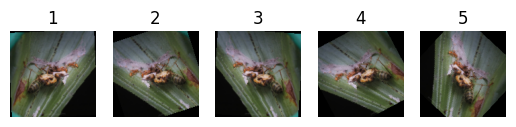

In [ ]:
# visualize random aug
import matplotlib.pyplot as plt

transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor()
])

hymenoptera_aug = Hymenoptera(root_dir="../data/hymenoptera_data/train", transform=transform_aug)

for i in range(5):
    img, label = hymenoptera_aug[1]  # visualize image(idx=1)
    img = img.permute(1, 2, 0)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(i+1)
    plt.axis("off")

plt.tight_layout
plt.show()

